<a href="https://colab.research.google.com/github/victor-torres05/Projeto---Uber-Data-Analytics/blob/main/Projeto_Uber_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bibliotecas utilizadas no projeto**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit

**Importação da Base**

In [2]:
base = pd.read_csv("/content/drive/MyDrive/Projetos/Uber - Data Analytics/ncr_ride_bookings.csv")

**Criação de novas colunas**

In [3]:
# Coluna Cancelled_Binary
base["Cancelled_Binary"] = base["Booking Status"].apply(lambda x: 0 if x == "Completed" else 1)

# Colunas binárias para as avaliações dos Clientes e Motoristas
base["Has_Driver_Rating"] = base["Driver Ratings"].notnull().astype(int)
base["Has_Customer_Rating"] = base["Customer Rating"].notnull().astype(int)

# Criação das Colunas de Tempo para o Modelo
base["Date"] = pd.to_datetime(base["Date"], errors="coerce")
base["Hour"] = base["Time"].str.slice(0, 2).astype(int)
base["DayOfWeek"] = base["Date"].dt.dayofweek
base["IsWeekend"] = base["DayOfWeek"].isin([5, 6]).astype(int)
base["IsPeakHour"] = (
    base["Hour"].between(7, 9) |
    base["Hour"].between(17, 20)
).astype(int)

# Coluna para identificar tempos de espera altos, horários de pico e a velocidade média do motorista
base["High_VTAT"] = (base["Avg VTAT"] > 8).astype(int)
base["Distance_CTAT_Ratio"] = base["Avg CTAT"]/(base["Ride Distance"] + 1)
base["CTAT_Per_Hour"] = base["Avg CTAT"]/(base["Hour"] + 1)

**Get Dummies e Criação da base para o modelo**

In [4]:
# Copiando só as colunas que interessam
df_model = base[[
    "Ride Distance", "Avg CTAT", "Avg VTAT", "Booking Value",
    "Has_Driver_Rating", "Has_Customer_Rating","Payment Method",
    "Cancelled_Binary", "High_VTAT","Hour", "DayOfWeek", "IsWeekend",
    "IsPeakHour","Distance_CTAT_Ratio","CTAT_Per_Hour"]].copy()

# Aplicando get_dummies nas colunas categóricas
df_model = pd.get_dummies(df_model, columns=["Payment Method"], drop_first=True)

**Código do modelo de ML (Regressão Logística)**

In [5]:
# Substiuição de valores vazios pela mediana de sua respectiva coluna
num_cols = ["Ride Distance","Avg CTAT","Avg VTAT","Booking Value","Distance_CTAT_Ratio","CTAT_Per_Hour"]
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Atribuição de features e target
X = df_model.drop(["Cancelled_Binary", "Has_Driver_Rating", "Has_Customer_Rating"], axis=1)
y = df_model["Cancelled_Binary"]

# Separação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização dos Dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Treinamento do Modelo
model = LogisticRegression(max_iter=2000, solver="saga", n_jobs=-1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Avaliação do Modelo
print("Acc:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acc: 0.8806
[[16181  2419]
 [ 1163 10237]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     18600
           1       0.81      0.90      0.85     11400

    accuracy                           0.88     30000
   macro avg       0.87      0.88      0.88     30000
weighted avg       0.89      0.88      0.88     30000



**Importância das Features**

Importância das Features (Coeficientes Absolutos)
                       feature      coef
0                Ride Distance -1.952208
13          Payment Method_UPI -1.684432
9          Distance_CTAT_Ratio -1.584574
14  Payment Method_Uber Wallet -1.003288
10               CTAT_Per_Hour -0.931543
11  Payment Method_Credit Card -0.930280
12   Payment Method_Debit Card -0.843542
4                    High_VTAT -0.518488
3                Booking Value -0.278934
2                     Avg VTAT  0.240979
5                         Hour -0.208331
1                     Avg CTAT -0.131602
7                    IsWeekend  0.037791
6                    DayOfWeek -0.006759
8                   IsPeakHour -0.002304


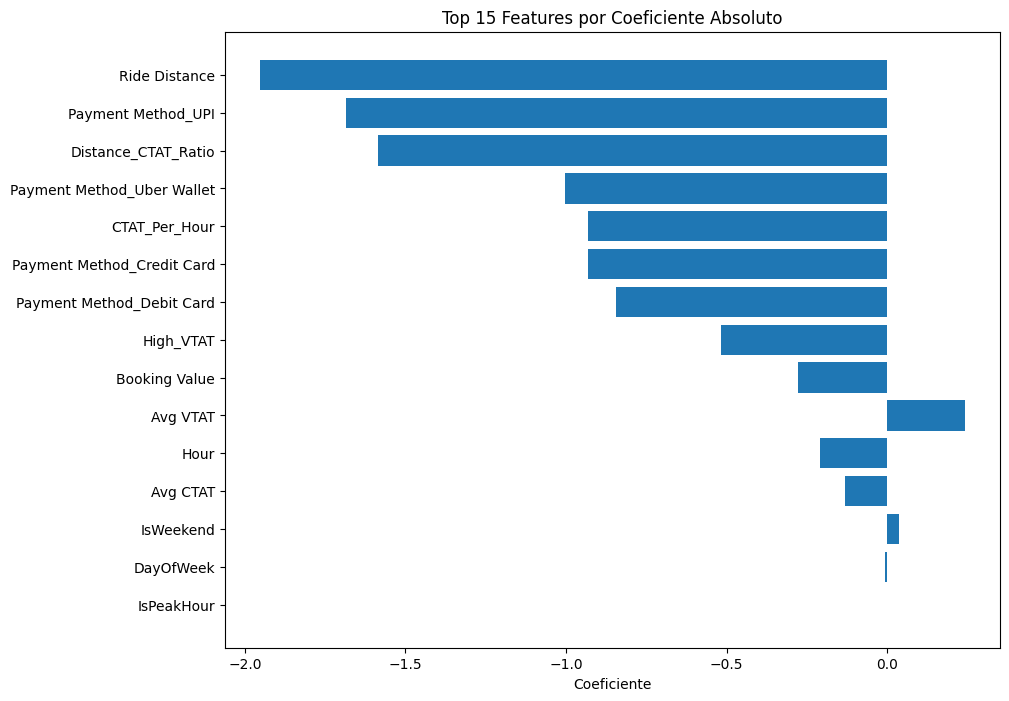

In [6]:
# Pegando os nomes das colunas após o get_dummies e os coeficientes
feature_names = X.columns
coef = model.coef_[0]

# Criando um DataFrame para ordenar
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
}).sort_values(by="coef", key=abs, ascending=False)

print("Importância das Features (Coeficientes Absolutos)")
print(coef_df)

# Gráfico simples para visualizar
plt.figure(figsize=(10, 8))
plt.barh(coef_df['feature'].iloc[:15], coef_df['coef'].iloc[:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Features por Coeficiente Absoluto")
plt.xlabel("Coeficiente")
plt.show()


**Gráfico Shap**

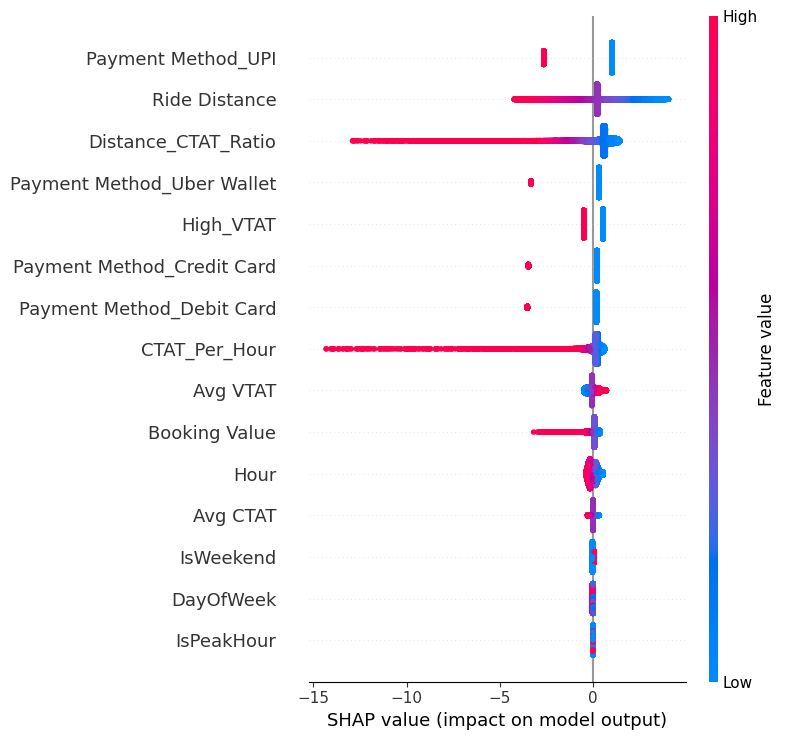

In [ ]:
# Criando o explainer usando os dados padronizados
explainer = shap.LinearExplainer(model, X_train_scaled)

# Calculando os SHAP values no teste
shap_values = explainer.shap_values(X_test_scaled)

# Gráfico geral — mostra quais features mais influenciam o modelo
shap.summary_plot(shap_values, X_test, max_display=15)

**Código do Modelo de ML (XGBooster)**

In [ ]:
features_final = [
    "Ride Distance","Avg VTAT", "Booking Value",
    "Hour", "DayOfWeek", "IsWeekend", "IsPeakHour",
    "Payment Method_Credit Card", "Payment Method_Debit Card",
    "Payment Method_UPI", "Payment Method_Uber Wallet"]

X = df_model[features_final]
y = df_model["Cancelled_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9413777777777778
Matriz de Confusão:
[[27866    34]
 [ 2604 14496]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     27900
           1       1.00      0.85      0.92     17100

    accuracy                           0.94     45000
   macro avg       0.96      0.92      0.94     45000
weighted avg       0.95      0.94      0.94     45000



**Importância das Features**

In [ ]:
importances = xgb.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

                       Feature  Importance
0                Ride Distance    0.545809
2                Booking Value    0.146334
9           Payment Method_UPI    0.080171
8    Payment Method_Debit Card    0.070173
7   Payment Method_Credit Card    0.056592
1                     Avg VTAT    0.053700
10  Payment Method_Uber Wallet    0.033628
3                         Hour    0.003528
5                    IsWeekend    0.003487
4                    DayOfWeek    0.003463
6                   IsPeakHour    0.003115


**Gráfico (Importância das Features)**

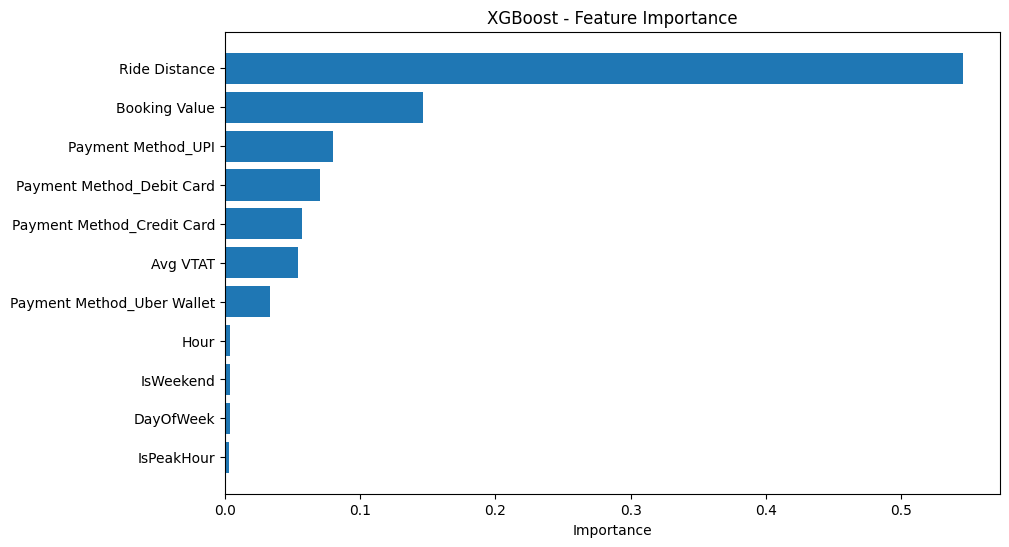

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance")
plt.show()

**Treino do Modelo (com scale_pos_weight)**

In [7]:
features_final = [
    "Ride Distance","Avg VTAT", "Booking Value",
    "Hour", "DayOfWeek", "IsWeekend", "IsPeakHour",
    "Payment Method_Credit Card", "Payment Method_Debit Card",
    "Payment Method_UPI", "Payment Method_Uber Wallet"]

X = df_model[features_final]
y = df_model["Cancelled_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.6,
    eval_metric="logloss",
    random_state=42)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Avaliação padrão (threshold = 0.5)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Avaliação padrão (threshold = 0.5)
Accuracy: 0.9402888888888888
Matriz de Confusão:
[[27796   104]
 [ 2583 14517]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     27900
           1       0.99      0.85      0.92     17100

    accuracy                           0.94     45000
   macro avg       0.95      0.92      0.93     45000
weighted avg       0.94      0.94      0.94     45000

